# Postprocessing & Morphology Analysis

This notebook provides tools for analyzing and visualizing aggregate and primary-particle morpholgoy results generated by SAGE models. It operates on saved CSV outputs from `SAGE_ANALYZE.ipynb` and allows for various types of visualizations and customization without requiring loading of trained models or performing inference passes.

This notebook loads the results generated by models in `SAGE_ANALYZE` for use in various visualization and plotting functions, such as particle size distributions, etc.

# Table of Contents

[1. Environment Initialization and Setup](#1-environment-initialization-and-setup)  

[2. Dataset Loading and Configuration](#2-dataset-loading-and-configuration)  

[3. Method and Plot Configuration](#3-method-and-plot-configuration)
- [3.1 Plot Defaults](#31-plot-defaults)
- [3.2 Custom Methods Styles](#32-custom-method-styles)

[4. Primary Particle Analysis](#4-primary-particle-analysis)  
- [4.1 Particle Size Distributions](#41-particle-size-distributions)
- [4.2 Primary-particle Parity Plot](#42-primary-particle-parity-plot)

[5. Aggregate Morphology Analysis](#5-aggregate-morphology-analysis)
- [5.1 Prediction-Ground Truth Agreement](#51-prediction-ground-truth-agreement)
- [5.2 Error Distributions (Boxplots)](#52-error-distributions-boxplots)
- [5.3 Method Legend Generation](#53-method-legend-generation)

[6. Confidence Threshold Comparisons](#6-confidence-threshold-comparisons)
- [6.1 Convert model names to confidence threshold versions](#61-convert-model-names-to-confidence-threshold-versions)
- [6.2 Select Model and Confidence Thresholds](#62-select-model-and-confidence-thresholds)
- [6.3 Morphology Analysis (Confidence Comparisons)](#63-morphology-analysis-confidence-comparisons)

# 1. Environment Initialization and Setup


This section imports required libraries, configures the SAGE project directory structure and imports the custom `postprocesser` module used throughout the notebook. The postprocessor contains the data loading, analysis, and visualization functions used for morphology evaluation and figure generation.


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

import pprint
import os
import sys


from scipy.stats import gmean, gstd


# Project directory setup - CHANGE 
ROOT_DIR = os.path.abspath("../SAGE-fork")
PRETRAIN_DIR = os.path.join(ROOT_DIR, "pretrained_models")
MODEL_DIR = os.path.join(ROOT_DIR, "logs")
RESULTS_DIR = os.path.join(ROOT_DIR, "Results")
DATA_DIR = os.path.abspath(os.path.join(ROOT_DIR, "../../Data/logs")) #TODO REMOVE this?

# Add Mask RCNN to path and import
sys.path.append(ROOT_DIR)

import postprocesser as ppr


# 2. Dataset Loading and Configuration

Load primary-particle and aggregate morphology measurements for the selected reference dataset. Aggregate metrics are converted to their corresponding three-dimensional estimates and filtered to the selected confidence threshold where applicable.

This section defines the global dataset context for the notebook and loads all morphology results associated with the selected reference dataset.

`REF_DATASET` specifies the benchmark dataset used for all analyses in this notebook. It determines which set of model predictions and ground truth morphology results are loaded. This notebook is focused on statistical comparison and visualization of morphology metrics, rather than annotation inspection or image-level visualization.

`CONF_THRESHOLD` defines the active confidence threshold used when loading primary-particle results. In addition, it is used to filter aggregate-level results to prevent double-counting entries when multiple model outputs exist across different confidence thresholds.

**NOTE** - to compare a model at different confidence threhsolds, see section (insert ref)

Using these settings, the notebook loads:

- Primary particle morphology results for all models evaluated on the dataset (`pp_df`)
- Aggregate Morphology results for the same dataset (`aggs`)


Aggregate morphology metrics are the converted into derived 3D equivalents:

- 3D Radius of Gyration 
- 3D Fractal Dimension

These derived metrics are used throughout downstream morphology comparisons and error analysis

In [ ]:
#Reference dataset & confidence threshold
REF_DATASET = "Final_Testv1_norm"
CONF_THRESHOLD = 0.6

#Dataset-specific paths
DATASET_RESULTS_DIR = os.path.join(RESULTS_DIR, REF_DATASET)

PP_INFO_FOLDER = os.path.join(DATASET_RESULTS_DIR, "PP_Info")
AGGREGATE_CSV = os.path.join(DATASET_RESULTS_DIR, "Aggregate_info.csv")
FULL_SUMMARY_CSV = os.path.join(DATASET_RESULTS_DIR, "Full_Summary.csv")

# Load primary-particle and aggregate morphology results
pp_df = ppr.load_PP_info(PP_INFO_FOLDER, 
                         shorten=False, 
                         conf_filter=CONF_THRESHOLD)

aggs = pd.read_csv(AGGREGATE_CSV)

#convert aggregate metrics to 3D equivalents
aggs = ppr.convert_to_3D_fractal_dim(aggs)
aggs = ppr.convert_3D_Rg(aggs)

#conf threshold filtering to aggregate metrics
aggs = aggs[
    (aggs["conf_threshold"].isna())
    | (aggs["conf_threshold"] == CONF_THRESHOLD)] 



# 3. Method and Plot Configuration

This section defines global plotting behavior and method-specific styling used across all visualization functions in the notebook. These settings control figure appearance, legends, markers, and consistent visual encoding of different methods.

## 3.1 Plot Defaults

`PLOT_DEFAULTS` provides a centralized configuration for figure sizing, styling behavior, and shared visualization parameters. These defaults ensure consistency across all plots, including boxplots, distributions, morphology comparisons, and confidence threshold analyses. 

Any function-specific styling (e.g., marker types, colors, or line styles) is applied on top of these defaults.

In [3]:
print("Current plot defaults:")
pprint.pprint(ppr.PLOT_DEFAULTS)

Current plot defaults:
{'alpha': 0.8,
 'autoscale': True,
 'bin_size': 1.25,
 'buffer_ratio': 0.05,
 'diameter_styles': {'dp': {'label': 'Area Equiv. Dia.',
                            'linestyle': '-',
                            'marker': 'o'},
                     'feret': {'label': 'Max Feret Dia.',
                               'linestyle': '--',
                               'marker': 's'},
                     'min_feret': {'label': 'Min Feret Dia.',
                                   'linestyle': ':',
                                   'marker': '^'}},
 'dpi': 100,
 'error_margin': 0.25,
 'error_style': {'color': None},
 'figsize': (12, 8),
 'filter_small': False,
 'fontsize_axes': 20,
 'fontsize_legend': 14,
 'fontsize_ticks': 16,
 'fontsize_title': 24,
 'gt_method': 'Final_Testv1_norm',
 'layout': 'row',
 'legend_loc': 'best',
 'linestyle': '-',
 'linewidth': 3,
 'log_scale': False,
 'marker': 'o',
 'marker_edgecolor': 'black',
 'marker_size': 100,
 'mode': 'single',
 'norm

## 3.2 Custom Method Styles

This section defines custom visualization styles for each method used in the analysis.

The `custom_registry` controls how methods are displayed across all plots, including labels, colors, markers, and other figure-specific styling options. These settings are used by the plotting functions to ensure consistent visual encoding of each model throughout the notebook.

Each entry in the registry corresponds to a method name and can define:

- Display label (used in legends and axes)
- Color encoding
- Marker type and size
- Plot-specific styling (PSD, scatter, error plots)

After definition, the registry is registered globally using `ppr.register_methods()`, making these styles available to all downstream visualization functions.

In [4]:
custom_registry = {
    "Final_Testv1_norm": {
        "label": "Manual",
        "color":"#000000",
        "psd_style": {"linestyle":"-","marker":""},
        "scatter_style": {"marker":"o","size":150,"edgecolor":"black"},
        "error_style": {}
    },

    "SAGE_1_E1": {
        "label": r"SAGE$_1$",
        "color":"#a618b3",
        "psd_style": {"linestyle":"-","marker":""},
        "scatter_style": {"marker":"o","size":350,"edgecolor":"black"},
        "error_style": {}
    },

    "SAGE_2_E2": {
        "label": r"SAGE$_2$",
        "color":"#1fb43f5e",
        "psd_style": {"linestyle":"-","marker":""},
        "scatter_style": {"marker":"^","size":350,"edgecolor":"black"},
        "error_style": {}
    },

    "SAGE_1_exp_N_E0025": {
        "label":  r"$\mathrm{SAGE}_{1\!-\!\mathrm{exp}\!-\!\mathrm{N}}$",
        "color":"#f01414ba",
        "psd_style": {"linestyle":"-","marker":""},
        "scatter_style": {"marker":"*","size":400,"edgecolor":"black"},
        "error_style": {}
    },

    "SAGE_1_exp_E0033": {
        "label":  r"$\mathrm{SAGE}_{1\!-\!\mathrm{exp}\!}$",
        "color":"#1435f0b8",
        "psd_style": {"linestyle":"-","marker":""},
        "scatter_style": {"marker":"*","size":400,"edgecolor":"black"},
        "error_style": {}
    },

    


}

ppr.register_methods(custom_registry)



The active registry can then be instpected with `ppr.inspect_methods`, separating methods listed in the loaded dataframe from ones with custom styles defined above.

In [5]:
ppr.inspect_methods(pp_df, registry=ppr.METHOD_REGISTRY)

Methods in loaded DataFrame
 - FV1_maskonly_test1_augm_E0016
 - Final_Testv1_norm
 - Fv1_COCO_PPcov_2stage_augm_bestAP50_E0040
 - Fv1_COCO_PPcov_2stage_augm_bestAPrange_E0024
 - Fv1_NotNorm_fullOG_E0033
 - Fv1_SAGE2_OLD_mini_E0055
 - Fv1_new_OGhead_norm_E0025
 - Fv1_norm_CovLeak_2stage_augm_E0036
 - Fv1_norm_PPcov_4stage_bestAP50_E0065
 - Fv1_norm_PPcov_4stage_bestAPrange_E0073
 - Fv1_norm_PPcov_heads_5plus_augm_bestAP50_E0023
 - Fv1_norm_PPcov_heads_5plus_augm_bestAPrange_E0034
 - Fv1_norm_std_CL_fullres_E0024
 - Fv1_norm_std_cov_only_E0028
 - Fv1_norm_std_covleak_E0032
 - Fv1_norm_std_leak_only_E0027
 - Fv1_norm_std_pphead_nocovleak_full_E0029
 - New_synth_E0089
 - SAGE_0_E0
 - SAGE_1_E1
 - SAGE_1_exp_E0033
 - SAGE_1_exp_N_E0025
 - SAGE_2_E2
 - new_synth_oghead_E0060
------------------------------------------------------------
Methods in METHOD_REGISTRY:
  - Final_Testv1_norm
  - SAGE_1_E1
  - SAGE_1_exp_E0033
  - SAGE_1_exp_N_E0025
  - SAGE_2_E2
-------------------------------------

# 4. Primary Particle Analysis

## 4.1 Particle Size Distributions

Particle size distributions (PSDs) provide a statistical description of the primary particle diameters present within a dataset. They are commonly used to characterize soot morphology, quantify particle size variability, and compare particle populations across different datasets, experimental conditions, or segmentation methods.

When manual measurements are available, PSDs can be used to evaluate how well model predictions reproduce the underlying particle size characteristics, including the central tendency, spread, and overall distribution shape. However, PSD analysis is also useful for exploratory analysis and model-to-model comparisons when reference measurements are unavailable.

The primary interface for generating PSD visualizations is plot_psd_wrapper(). This wrapper applies default plotting settings, automatically generates method-specific styles from the method registry, and forwards plotting options to the underlying PSD plotting functions. Most PSD figures can be generated by specifying the methods to plot and the desired diameter definition, while additional behavior can be controlled through keyword arguments.

**PSD Plot Options (plot_psd_wrapper)**

Core options commonly used when generating PSD figures are summarized below. Additional customization options are available through plot_psd_wrapper and PLOT_DEFAULTS.

| Option             | Type                       | Default       | Description                         |
| ------------------ | -------------------------- | ------------- | ----------------------------------- |
| `methods`          | list[str] or None          |all methods in `pp_df`| Methods to include. Uses all methods in `pp_df` if omitted|     
| `dia_type`         |str or dict                 | `'equiv'`      | diameter type (`equiv`, `feret`, `min_feret`) or per-method mapping in a dictionary|
| `plot_type`        |str                         | `'hist'`      | Type of PSD plot ( `'hist'`, `'kde'`, `'bar'` )|                   |
| `normalize`        | bool                       | `False`       | Use density instead of count        |
| `log_scale`        | bool                       | `False`       | Use logarithmic y-axis scaling      |
| `filter_small`     | bool                       | `False`       | Remove small particles              |
| `bin_size`         | float or None              | `PP_BIN_SIZE` | Histogram bin width                 |
| `unit`             | str                        | `PP_UNIT`     | Diameter unit (e.g. `"nm"`)         |
| `alpha`            | float                      | 0.8           | Transparency                        |
| `linewidth`        | float                      | 3             | Line width                          |
| `marker_size`      | int                        | 100           | Marker size (if used)               |
| `marker_edgecolor` | str                        | `"black"`     | Marker edge color                   |
| `show_metrics`     | bool                       | `True`        | Show geometric mean ± std in legend |

Plot settings are applied in the following order of precedence:

1. `PLOT_DEFAULTS`
2. `plot_kwargs`
3. Direct keyword arguments (`kwargs`)

Values specified later override earlier settings.

Count


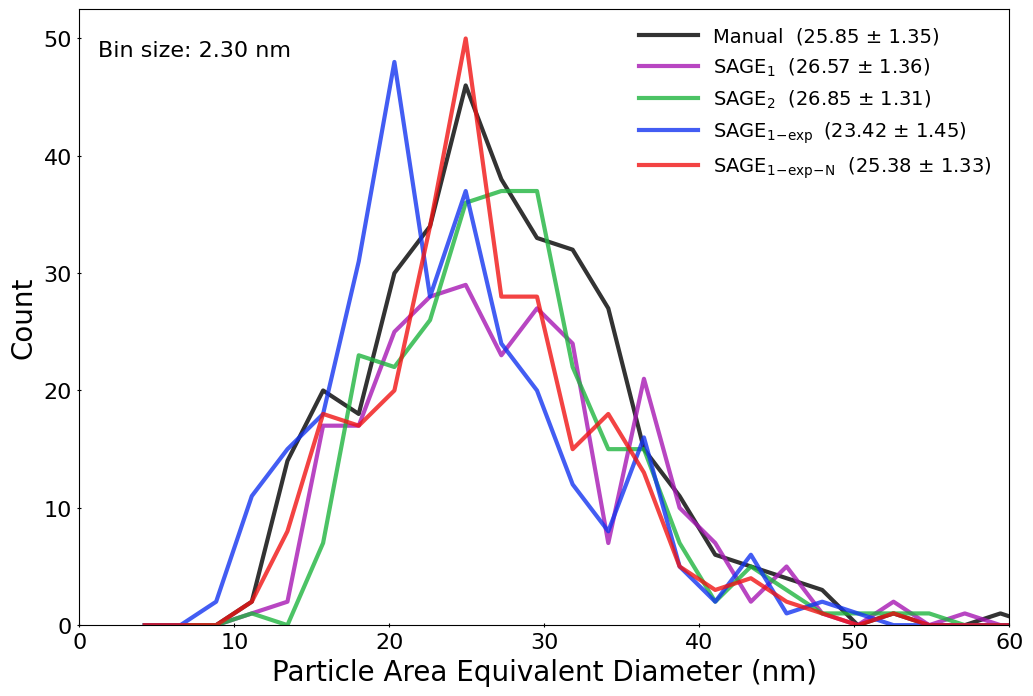

In [6]:
methods = [
    "Final_Testv1_norm",
    "SAGE_1_E1",
    "SAGE_2_E2",
    "SAGE_1_exp_E0033",
    "SAGE_1_exp_N_E0025",
]

fig, ax = ppr.plot_psd_wrapper(
    pp_df,
    methods=methods,
    plot_type="hist",
    bin_size=2.3,
    xlim=(0,60)
)

## 4.2 Primary-particle Parity Plot



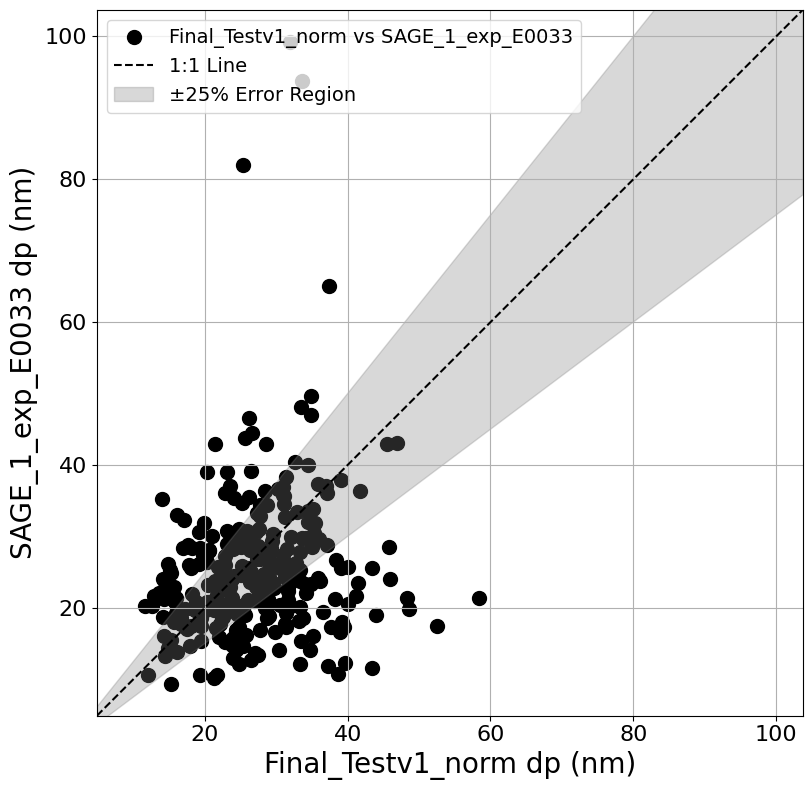

(<Figure size 1200x800 with 1 Axes>,
 <Axes: xlabel='Final_Testv1_norm dp (nm)', ylabel='SAGE_1_exp_E0033 dp (nm)'>)

In [7]:
#TODO - revisit parity plots for pp level

ppr.plot_parity_metric(df=pp_df,
                       method_x='Final_Testv1_norm',
                       method_y='SAGE_1_exp_E0033',
                       method_registry=ppr.METHOD_REGISTRY)

# 5. Aggregate Morphology Analysis

This section provides two complementary visualization tools for evaluating aggregate-level morphology predictions:
- `plot_metric_agreement` - prediction vs. ground truth comparison
- `plot_error_boxplots` - distribution of prediction errors relative to ground truth values

Both functions operate on the same dataset structure (aggs) and share a unified configuration system for metrics, styling, and layout control.

---

**Styling System**

Method styling (colors, labels, markers) is centrally defined in `METHOD_REGISTRY`.
This is resolved at runtime into plotting styles via `build_method_styles()` and passed internally as `method_styles`.

This ensures consistent visual encoding of methods across all plots.

---

**Common Metrics**

Metrics are specified as strings matching column names in `aggs`. 

| Metric | Description |
|----------|----------|
| `Rg [nm]` | 2D radius of gyration |
| `3D Rg [nm]` | 3D radius of gyration |
| `fractal_dim` | 2D fractal dimension |
| `3D Fractal Dimension` | 3D fractal dimension |
| `dp [nm] geo mean` | Geometric mean primary particle diameter |
| `coverage_score` | Coverage score |
| `leakage_frac` | Leakage fraction |

Additional numeric columns in `aggs` may also be plotted.

---

**Layout and Plot Configuration (`plot_kwargs`)**

All visualization behavior is controlled through a shared configuration dictionary:

```bash
{**PLOT_DEFAULTS, **plot_kwargs, **kwargs}
```

**Layout Controls (`plot_kwargs`)****

| Key | Description |
|------|-------------|
| `"mode": "single"` | Separate figure per metric |
| `"mode": "subplots"`| Multiple metrics in one figure |
| `"layout": "square"` | Balanced grid  |
| `"layout": "row"` | Single row layout |
| `"layout": "column"` | Single column layout |
| `"layout": (rows, cols)` | Custom grid shape |


**Common Plot Settings (`plot_kwargs`)**

|Key | Description |
|------|-------------|
| `figsize` |Figure size `(width,height)` |
| `dpi` | Figure resolution |
| `title` | Optional Plot title |
| `fontsize_*` |  Font sizes for titles/axes/ticks |
| `linewidth` |  line/Box edge thickness |
| `marker_size` | Size of scatter points/boxplot outliers (overrides preset style) |
|`show_legend` | Toggle legend visibility |
|`legend_loc` | Optional override for legend placement (agreement plots only)|
|`xlim`,`ylim` | Optional axis limits (overrides autoscaling if set) |

---


## 5.1 Prediction-Ground Truth Agreement

This section visualizes how well model predictions reproduce ground truth aggregate-level morphology metrics.

Each plot compares predicted values against ground truth values on a per-image (aggregate) basis.

---

**Plot Structure**

- Each point represents a single image/aggregate
- x-axis: ground truth metric value
- y-axis: predicted metric value
- The diagonal regerence line indicates perfect agreement (prediction=ground truth)


Metrics, method selection, styling, and layout are controlled via the shared plot_kwargs configuration system.

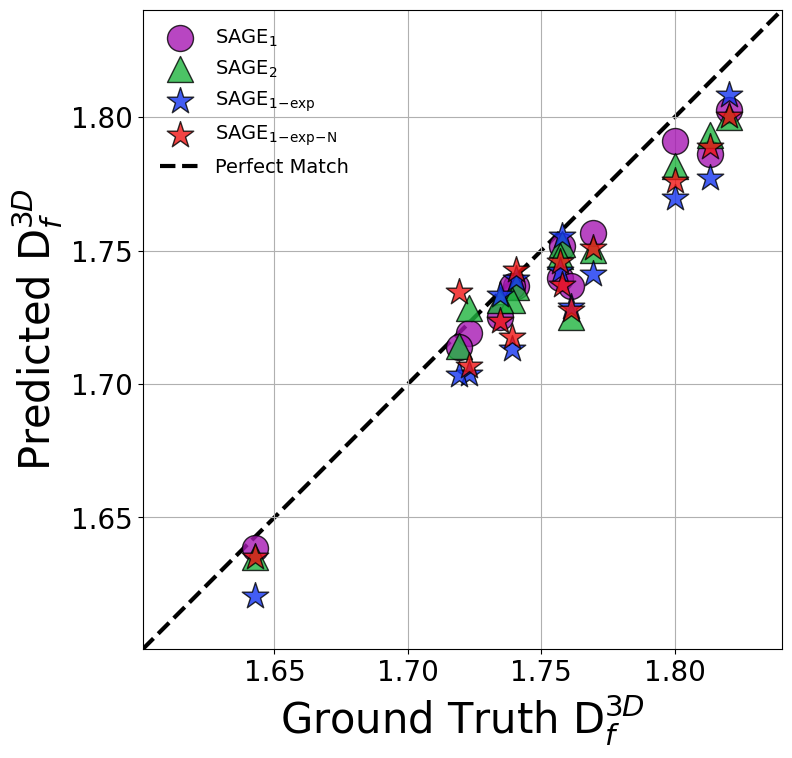

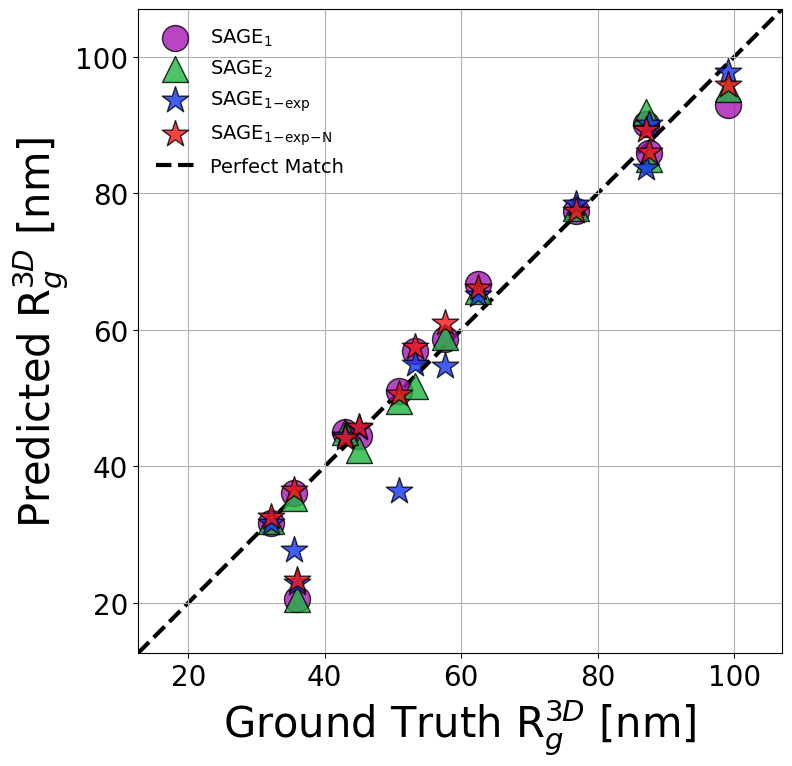

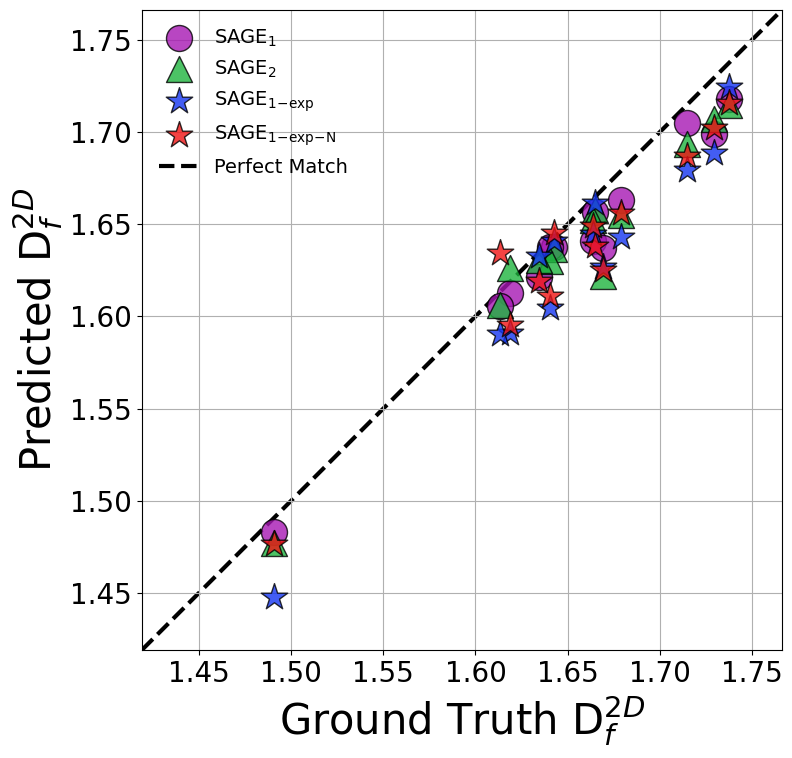

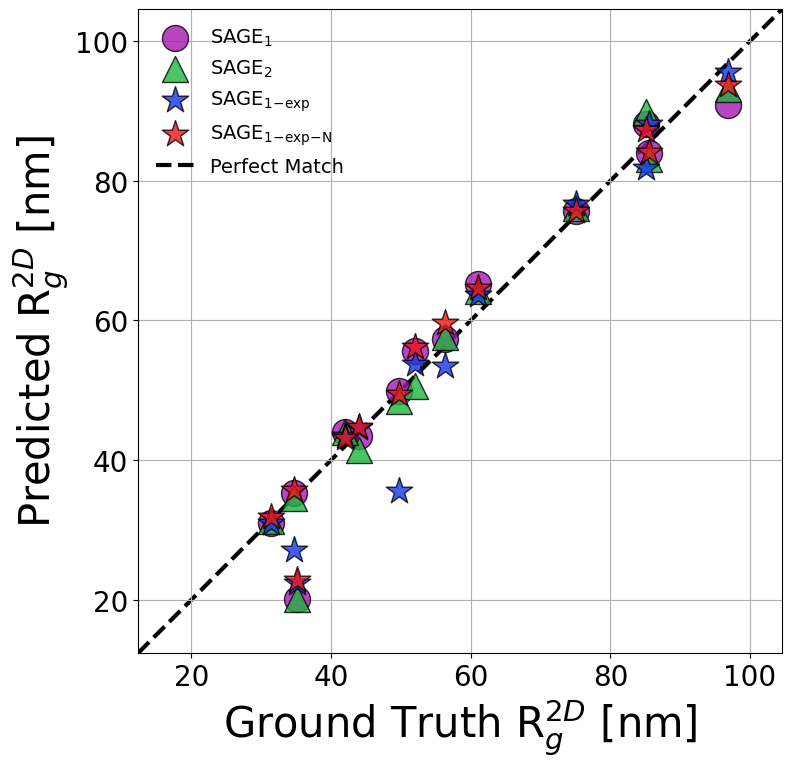

In [8]:
_ = ppr.plot_metric_agreement(aggs=aggs, 
                          metrics=['3D Fractal Dimension','3D Rg [nm]', 'fractal_dim','Rg [nm]'],
                          included_methods=methods,
                         
                          plot_kwargs = {
                            "mode": "single",
                            "fontsize_axes": 30,
                            "fontsize_ticks": 20 ,
                            "show_legend":  True,
                          } )

## 5.2 Error Distributions (Boxplots)

This section visualizes prediction error distributions across methods for aggregate-level morphology metrics.

Error is computed per image as a percent difference relative to ground truth.

Each boxplot summarizes the distribution of per-image (aggregate-level) errors for a given method and metric. Individual points are only shown for outliers and do not represent the full sample set.

---

**Plot Structure**
- Each boxplot shows the distribution of per-image errors for a given method and metric
- x-axis: method
- y-axis: percent error
- Outliers are shown as individual points and represent atypical cases only 

**Interpretation**
- Lower median error: better agreement with ground truth
- Smaller spread: more consistent predictions
- Outliers: specific failure cases or difficult images

**Additional Options**
| Option | Type | Default | Description |
|----------|------|----------|----------|
| `hardcoded_order` | list[str] | None | Manual ordering of methods on x-axis (use keys of methods) |
| `debug` | bool | False | Print diagnostic info |


**Notes**
- Ground truth is defined by `gt_method`
- Error is computed per image as percent difference from ground truth
- Required error columns (`{metric} error`) are generated automatically if not present
- Zero or missing ground truth values are excluded



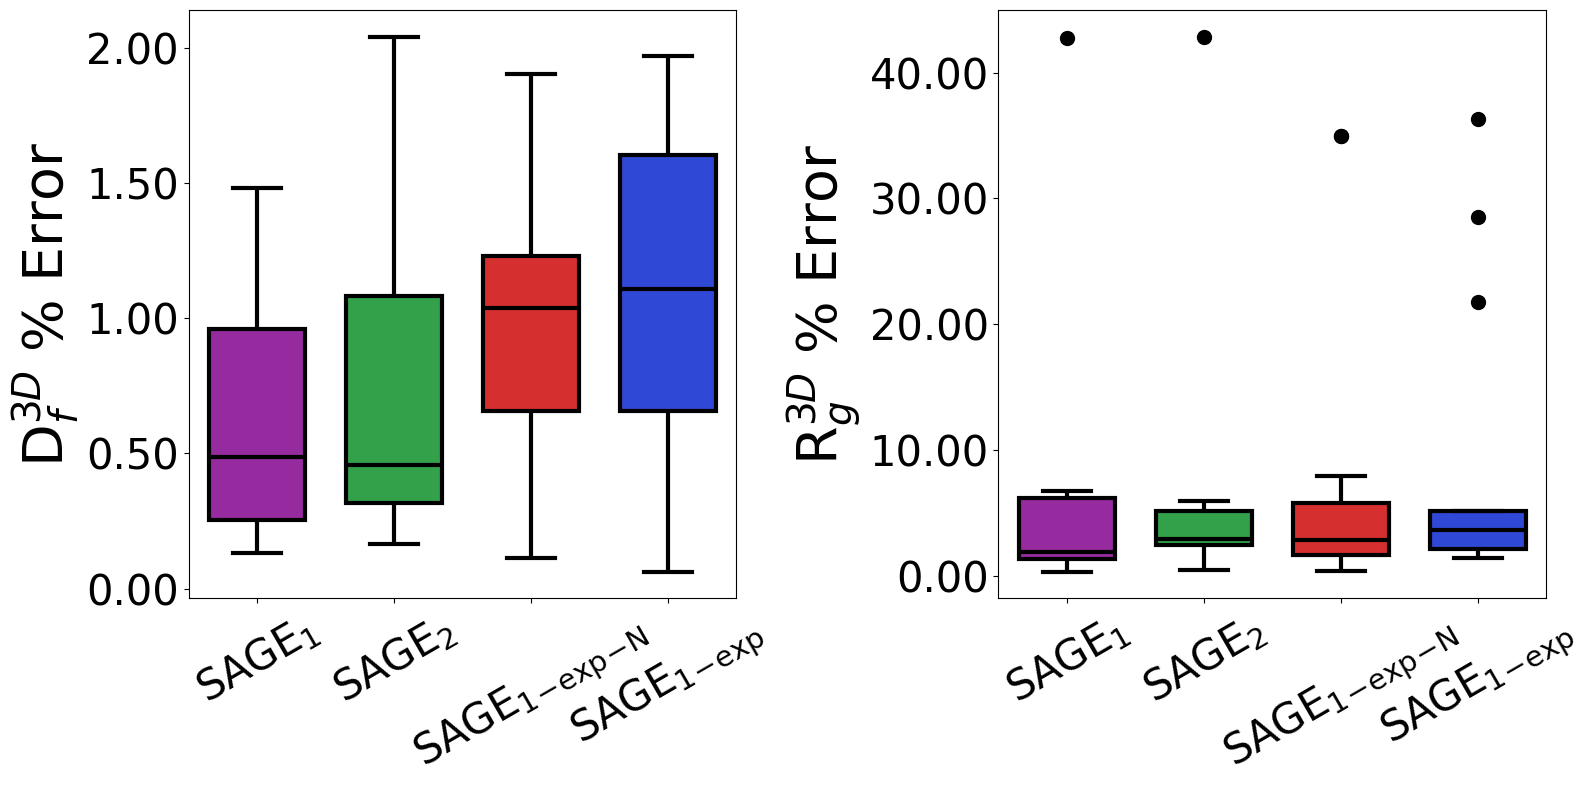

In [9]:
df_errors, figs, axes = ppr.plot_error_boxplots(aggs,
                        metrics=["3D Fractal Dimension",
                                 "3D Rg [nm]", 
                                 ],
                        included_methods=methods,
                        debug=False,
                        plot_kwargs = {
                              "fontsize_axes": 40,
                              "fontsize_ticks":30 ,
                              "marker_size": 10,
                              "show_legend": False,
                              "mode": "subplots",
                              "layout": "row"
                          } ,
                        
                        


     )

## 5.3 Method Legend Generation

This section generates a standalone legend figure based on the set of methods used in analysis.

The legend is constructed independently from plotting functions and is intended for use in figures, presentations, or papers where a consistent legend is required.

First, the methods are extracted and cleaned to remove the ground truth method using:

```python
    filtered_aggs = ppr.filter_aggs(aggs,
                            methods=methods)
    methods_clean = filtered_aggs["method"].unique()
```

The filtered method list is then passed to `create_method_legend_figure`, which generates a standalone legend using styling information defined in `METHOD_REGISTRY`:

```python
    legend_fig, legend_ax = ppr.create_method_legend_figure(methods_clean)
```

The resulting figure can be reused alongside agreement plots, error distributions, or other visualizations requiring a consistent method legend.

['SAGE_1_E1' 'SAGE_2_E2' 'SAGE_1_exp_N_E0025' 'SAGE_1_exp_E0033']


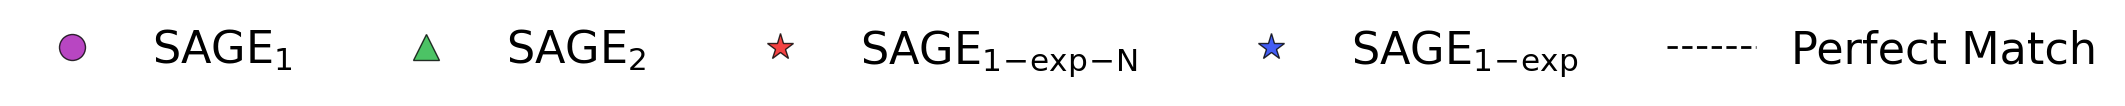

In [10]:
filtered_aggs = ppr.filter_aggs(aggs,
                            methods=methods)


methods_clean = filtered_aggs["method"].unique()

print(methods_clean)

legend_fig, legend_ax = ppr.create_method_legend_figure(methods_clean)

# 6. Confidence Threshold Comparisons

This section compares the behavior of a single model across muliple confidence thresholds. 

Confidence threshold comparisons are useful for understanding how threshold selection influences agreement with ground truth morphology measurements. By evaluating model behavior across a range of thresholds, users can identify settings that balance missed detections and false positives while maintaining accurate morphology characterization.

This can help guide threshold selection for future datasets where ground truth annotations are unavailable.

To enable these comparisons, each confidence threshold is treated as a separate method. This allows the existing PSD, morphology agreement, and error comparison functions to be reused without modification.


For example:

| Model | Confidence Threshold | Method Name |
|---------|---------|---------|
| `SAGE_1_exp_N_E0025` | `0.0` | `SAGE_1_exp_N_E0025_0.0` |
| `SAGE_1_exp_N_E0025` | `0.5` | `SAGE_1_exp_N_E0025_0.5` |
| `SAGE_1_exp_N_E0025` | `0.6` | `SAGE_1_exp_N_E0025_0.6` |
| `SAGE_1_exp_N_E0025` | `0.7` | `SAGE_1_exp_N_E0025_0.7` |


## 6.1 Convert model names to confidence threshold versions
First, load the morphology results containing all available confindence thresholds for the model and convert them into confidence-specific method names. This will convert *every* model in the saved files to the new naming convention. 

This is achieved by reloading the data as originally done earlier, but without any confidence threshold filtering. The function `add_conf_to_method()` is then used to convert the method names for each model's results at different thresholds.

In [11]:

# reload primary-particle and aggregate morphology results, but with no confidence threshold filter
pp_c = ppr.load_PP_info(PP_INFO_FOLDER, 
                         shorten=False, 
                         conf_filter=None)

aggs_c = pd.read_csv(AGGREGATE_CSV)

#convert aggregate metrics to 3D equivalents
aggs_c = ppr.convert_to_3D_fractal_dim(aggs_c)
aggs_c = ppr.convert_3D_Rg(aggs_c)

#convert method names to include confidence thresholds
pp_c = ppr.add_conf_to_method(pp_c)
aggs_c = ppr.add_conf_to_method(aggs_c)



## 6.2 Select Model and Confidence Thresholds

For confidence threshold comparisons, a single model should be selected. The comparison functions will then evaluate that model across one or more confidence thresholds.

The `get_conf_methods()` helper is used to collect the confidence-specific method names associated with a model.

If `thresholds=None`, all available confidence thresholds for the selected model are returned. Alternatively, specific thresholds may be provided to restrict the comparison.

Setting `include_ref=True` also includes the reference (ground truth) dataset when appropriate for the selected analysis. This should be included for any agreement or error comparisons, as ground truth information is required for those.

In [12]:
methods_conf = ppr.get_conf_methods(pp_c,
                               model_name = "SAGE_1_exp_N_E0025",
                               thresholds=None,
                               include_ref=True)

print(methods_conf)


['Final_Testv1_norm', 'SAGE_1_exp_N_E0025_0.0', 'SAGE_1_exp_N_E0025_0.5', 'SAGE_1_exp_N_E0025_0.6', 'SAGE_1_exp_N_E0025_0.7', 'SAGE_1_exp_N_E0025_0.8']


## 6.3 Morphology Analysis (Confidence Comparisons)

The `methods_conf` list contains confidence-specific method names for a single model. These methods can be passed directly into the existing morphology, PSD, and error comparison functions in the same way as done when comparing different models earlier in the notebook.

Because all entries correspond to the same underlying model, plot styling is automatically generated rather than drawn from the `METHOD_REGISTRY`. All previously described `plot_kwargs` options remain fully applicable.

If desired, these confidence-specific methods can also be added to the `METHOD_REGISTRY` to enforce consistent styling and labeling across figures.

Count


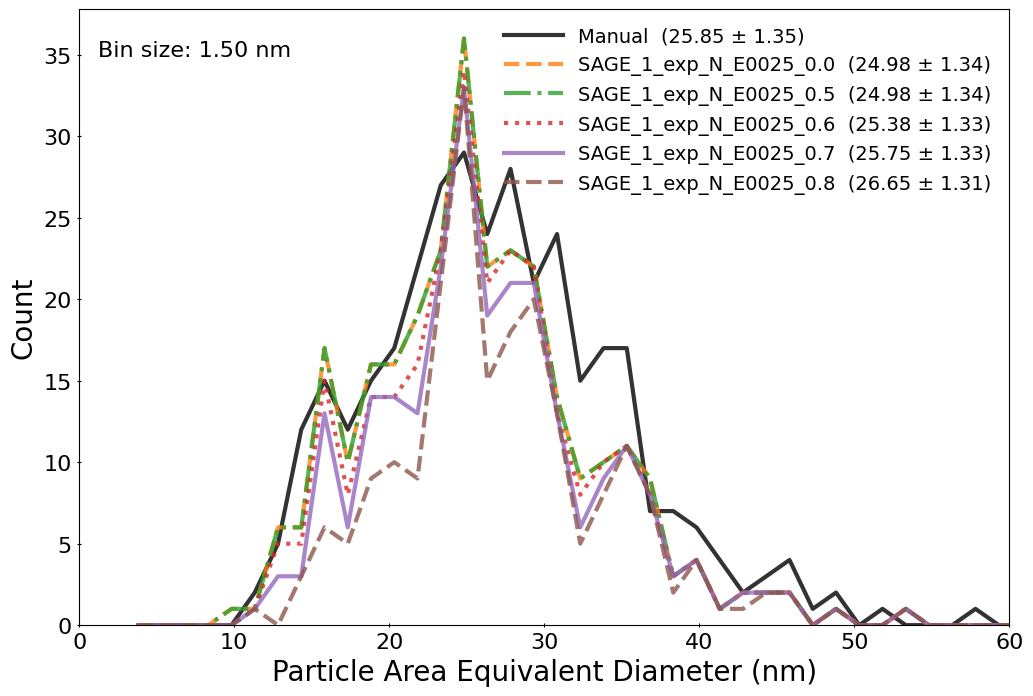

In [13]:
# PSD for method across conf thresholds:

methods = ["Final_Testv1_norm",
            "Fv1_new_OGhead_norm_E0025_0.0",
            "Fv1_new_OGhead_norm_E0025_0.6"]
           
# Plot normally
fig, ax = ppr.plot_psd_wrapper(pp_c, methods=methods_conf, plot_type="hist", bin_size=1.5,xlim=(0,60))

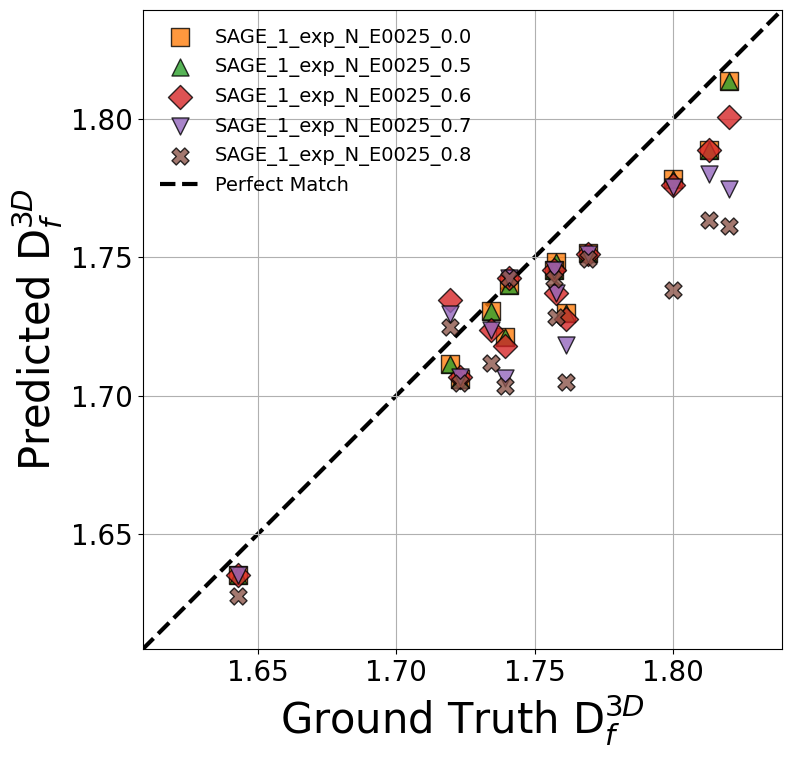

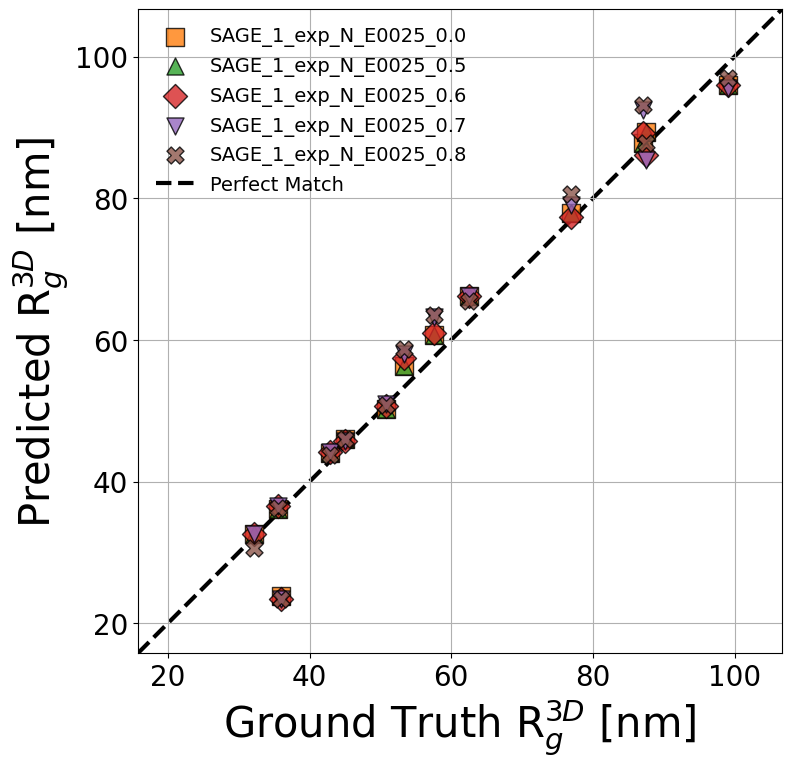

In [14]:
_ = ppr.plot_metric_agreement(aggs=aggs_c, metrics=['3D Fractal Dimension','3D Rg [nm]'],included_methods=methods_conf, plot_kwargs = {
                            "mode": "single",
                            "fontsize_axes": 30,
                            "fontsize_ticks": 20 ,
                            "show_legend":  True,}
)

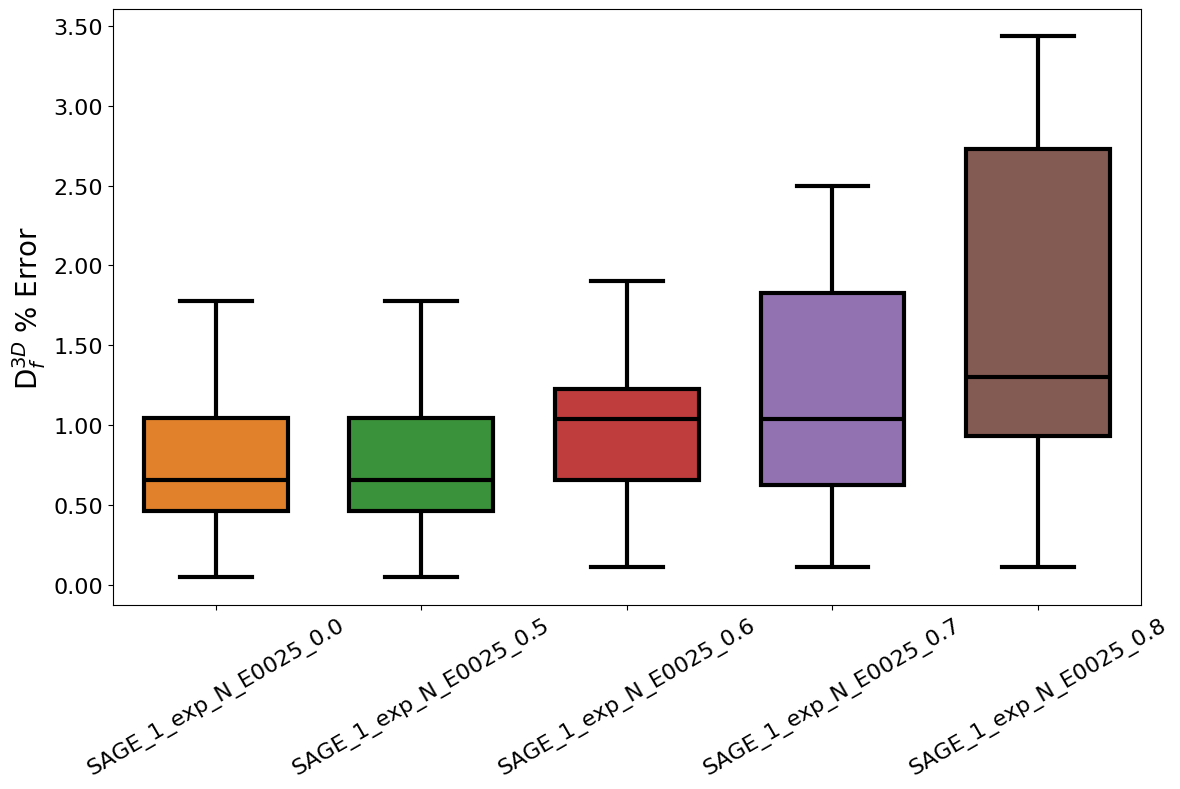

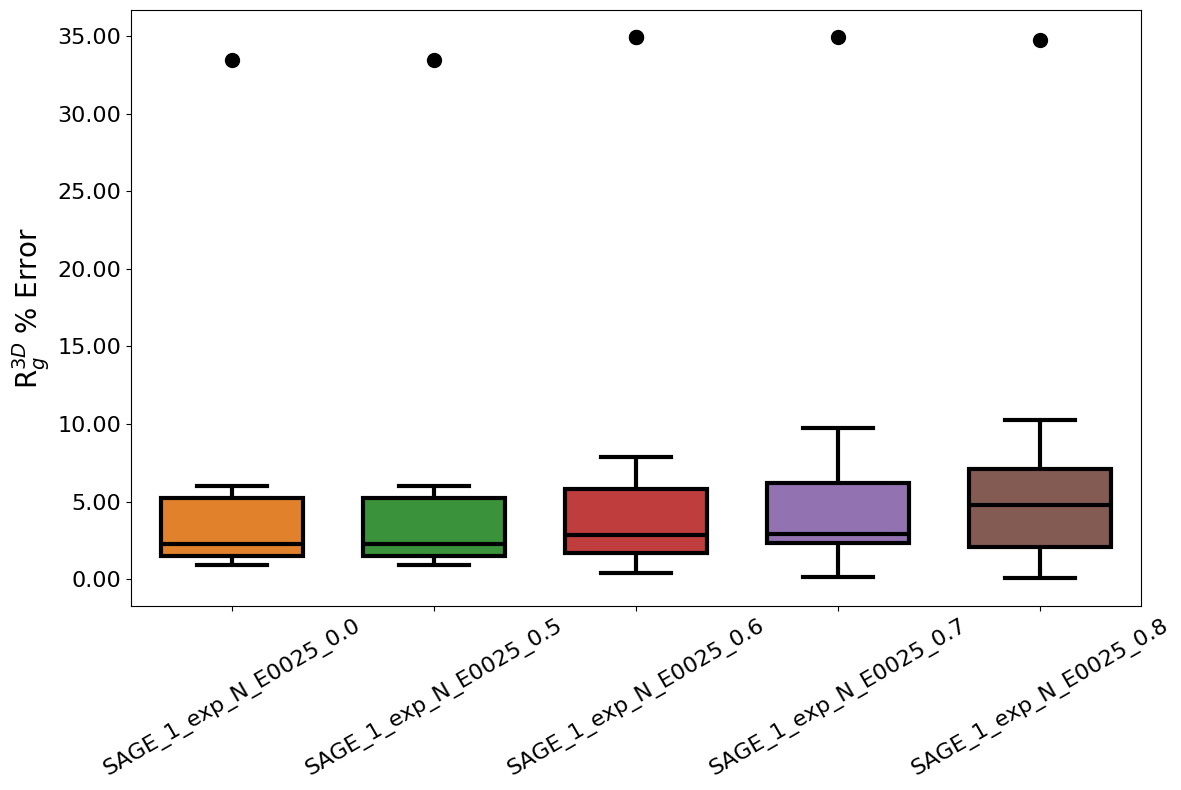

In [15]:
df_errors, figs, axes = ppr.plot_error_boxplots(aggs_c,
                        metrics=["3D Fractal Dimension","3D Rg [nm]"],
                        included_methods=methods_conf,
                        hardcoded_order=methods_conf,
                            plot_kwargs={
                                
                                "marker_size": 10
                            }
                        


     )